In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import random
import copy

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ---------------- DATA (augmentation reduces overfitting) ----------------
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR100('./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100('./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# ---------------- MODEL (pretrained helps a lot) ----------------
model = resnet18(weights="IMAGENET1K_V1")

# dropout added to reduce overfitting
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(512,100)
)

model = model.to(device)

# ---------------- FREEZE ALL ----------------
for p in model.parameters():
    p.requires_grad = False

# accuracy function
def accuracy_loader(model, loader):
    model.eval()
    correct,total=0,0
    with torch.no_grad():
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            out=model(x)
            _,pred=out.max(1)
            total+=y.size(0)
            correct+=pred.eq(y).sum().item()
    return correct/total

best_acc = accuracy_loader(model,testloader)
print("Initial test acc:",best_acc)

layers = {
    "layer1": model.layer1,
    "layer2": model.layer2,
    "layer3": model.layer3,
    "layer4": model.layer4
}

# ---------------- RANDOMIZED TRAINING ----------------
for i in range(40):

    print("\nIteration",i+1)

    # choose 1 or 2 layers randomly
    chosen_names = random.sample(list(layers.keys()), random.choice([1,2]))
    print("Unfreezing:",chosen_names)

    old_weights = copy.deepcopy(model.state_dict())

    # unfreeze chosen layers
    for name in chosen_names:
        for p in layers[name].parameters():
            p.requires_grad=True

    # FC ALWAYS train
    for p in model.fc.parameters():
        p.requires_grad=True

    optimizer = torch.optim.Adam(
        filter(lambda p:p.requires_grad,model.parameters()),
        lr=3e-4,
        weight_decay=1e-4   # key for overfitting
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3)

    loss_fn=torch.nn.CrossEntropyLoss()

    # training
    model.train()
    for epoch in range(3):
        for x,y in trainloader:
            x,y=x.to(device),y.to(device)

            optimizer.zero_grad()
            out=model(x)
            loss=loss_fn(out,y)
            loss.backward()
            optimizer.step()

        scheduler.step()

    train_acc = accuracy_loader(model,trainloader)
    test_acc  = accuracy_loader(model,testloader)

    print("Train:",train_acc)
    print("Test :",test_acc)

    if test_acc > best_acc:
        best_acc=test_acc
        print("✅ Improved")
    else:
        model.load_state_dict(old_weights)
        print("❌ Reverted")

    # freeze again
    for p in model.parameters():
        p.requires_grad=False

print("\nFinal best:",best_acc)

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import random
import copy
import os

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ---------------- DATA ----------------
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

# ---------------- MODEL ----------------
model = resnet18(weights="IMAGENET1K_V1")

model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(512, 100)
)

model = model.to(device)

# ---------------- FREEZE ALL ----------------
for p in model.parameters():
    p.requires_grad = False

# ---------------- ACCURACY FUNCTION ----------------
def accuracy_loader(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
    return correct / total

# ---------------- TRAINING SETUP ----------------
best_acc = accuracy_loader(model, testloader)
print("Initial test accuracy:", best_acc)

layers = {
    "layer1": model.layer1,
    "layer2": model.layer2,
    "layer3": model.layer3,
    "layer4": model.layer4
}

patience = 5
no_improve_count = 0
max_iterations = 40

# ---------------- RANDOMIZED TRAINING LOOP ----------------
for i in range(max_iterations):

    print("\n========== Iteration", i + 1, "==========")

    chosen_names = random.sample(
        list(layers.keys()),
        random.choice([1, 2])
    )

    print("Unfreezing:", chosen_names)

    old_weights = copy.deepcopy(model.state_dict())

    # Unfreeze selected layers
    for name in chosen_names:
        for p in layers[name].parameters():
            p.requires_grad = True

    # Always train FC
    for p in model.fc.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=3e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=3
    )

    loss_fn = torch.nn.CrossEntropyLoss()

    # -------- TRAIN --------
    model.train()

    for epoch in range(3):
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

        scheduler.step()

    # -------- EVALUATE --------
    train_acc = accuracy_loader(model, trainloader)
    test_acc = accuracy_loader(model, testloader)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)

    # -------- EARLY STOPPING --------
    if test_acc > best_acc:
        best_acc = test_acc
        no_improve_count = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Improved — Model Saved")
    else:
        model.load_state_dict(old_weights)
        no_improve_count += 1
        print("❌ Reverted | No Improve Count:", no_improve_count)

    # Freeze again
    for p in model.parameters():
        p.requires_grad = False

    # Stop if no improvement for patience rounds
    if no_improve_count >= patience:
        print("\n🛑 Early stopping triggered!")
        break

print("\nFinal Best Accuracy:", best_acc)
print("Best model saved as best_model.pth")

Using: cuda


100%|██████████| 169M/169M [00:02<00:00, 61.4MB/s] 


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s] 


Initial test accuracy: 0.0091

========== Iteration 1 ==========
Unfreezing: ['layer3']
Train Accuracy: 0.75712
Test Accuracy : 0.7054
✅ Improved — Model Saved

========== Iteration 2 ==========
Unfreezing: ['layer2', 'layer3']
Train Accuracy: 0.84694
Test Accuracy : 0.758
✅ Improved — Model Saved

========== Iteration 3 ==========
Unfreezing: ['layer1', 'layer3']
Train Accuracy: 0.89264
Test Accuracy : 0.7757
✅ Improved — Model Saved

========== Iteration 4 ==========
Unfreezing: ['layer4', 'layer1']
Train Accuracy: 0.94616
Test Accuracy : 0.7912
✅ Improved — Model Saved

========== Iteration 5 ==========
Unfreezing: ['layer3']
Train Accuracy: 0.97058
Test Accuracy : 0.7984
✅ Improved — Model Saved

========== Iteration 6 ==========
Unfreezing: ['layer3']
Train Accuracy: 0.97966
Test Accuracy : 0.7984
❌ Reverted | No Improve Count: 1

========== Iteration 7 ==========
Unfreezing: ['layer3', 'layer4']
Train Accuracy: 0.9772
Test Accuracy : 0.795
❌ Reverted | No Improve Count: 2

======

Model Loaded

✅ Accuracy: 0.8011

📊 Classification Report:
               precision    recall  f1-score   support

        apple       0.92      0.93      0.93       100
aquarium_fish       0.93      0.87      0.90       100
         baby       0.71      0.66      0.68       100
         bear       0.64      0.67      0.66       100
       beaver       0.67      0.68      0.68       100
          bed       0.83      0.80      0.82       100
          bee       0.82      0.87      0.84       100
       beetle       0.73      0.77      0.75       100
      bicycle       0.95      0.91      0.93       100
       bottle       0.95      0.87      0.91       100
         bowl       0.64      0.64      0.64       100
          boy       0.60      0.57      0.58       100
       bridge       0.85      0.90      0.87       100
          bus       0.81      0.78      0.80       100
    butterfly       0.86      0.76      0.81       100
        camel       0.75      0.85      0.79       100
     

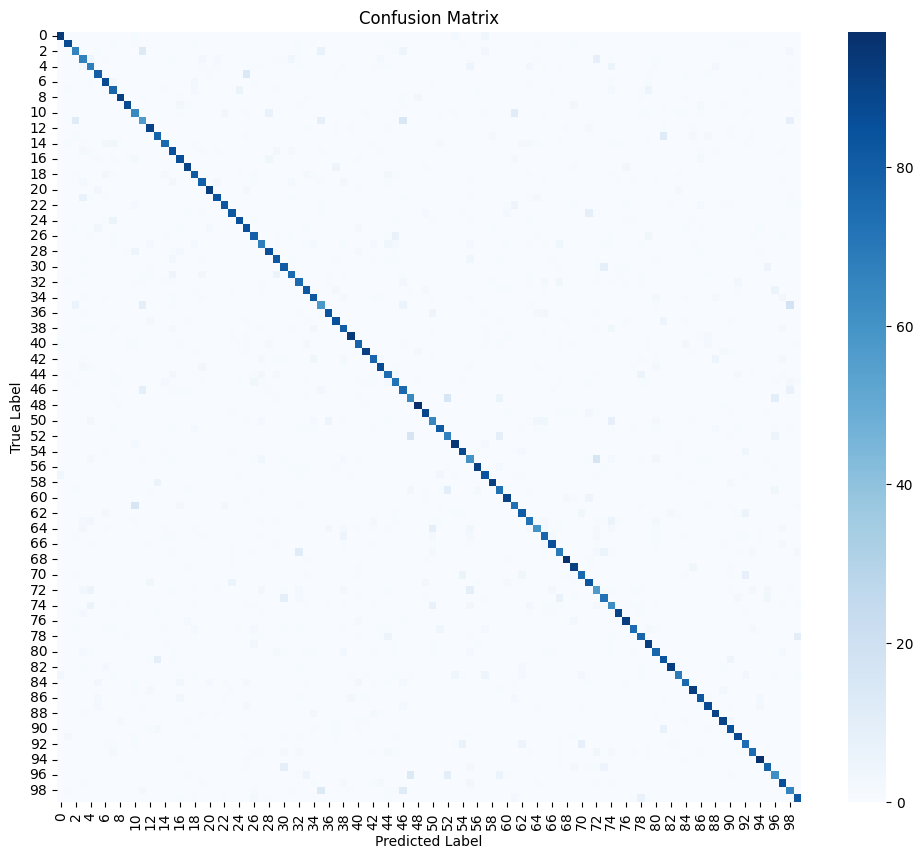

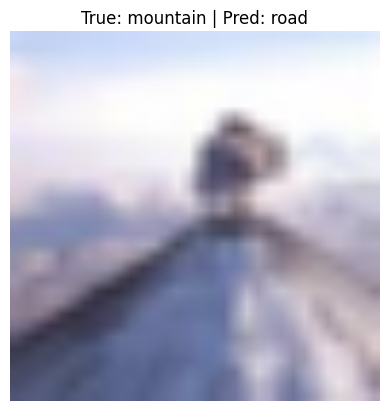

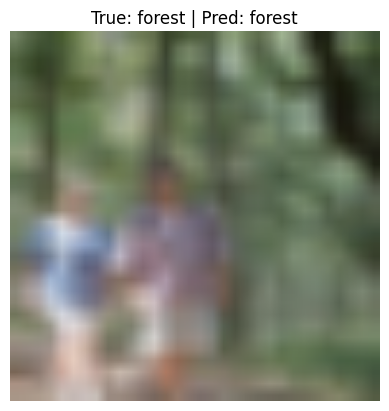

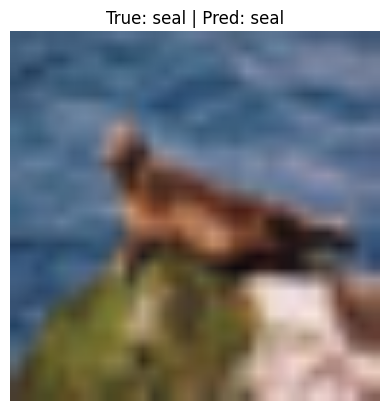

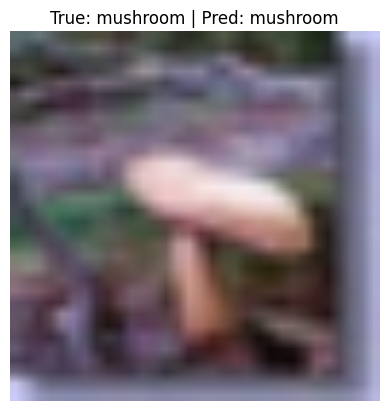

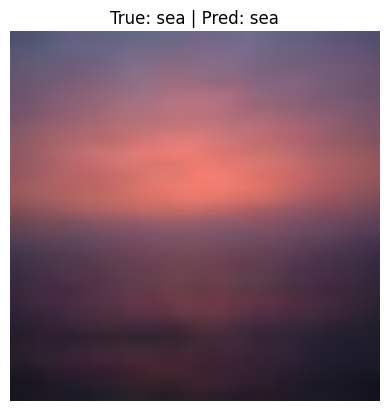

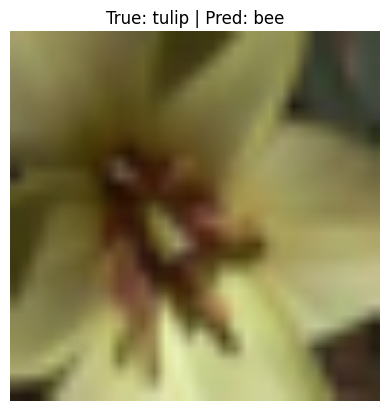

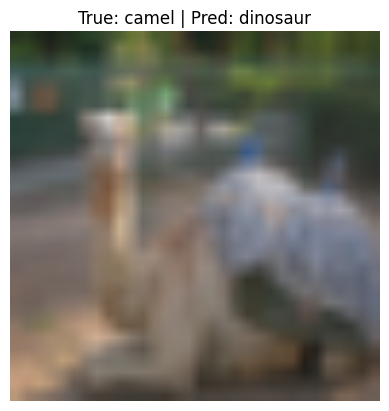

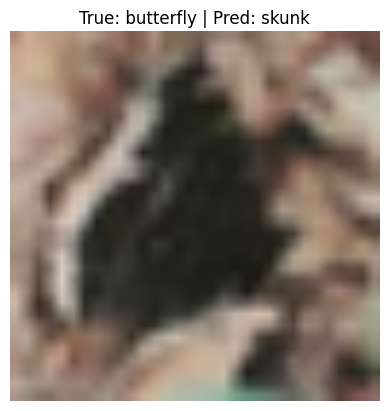

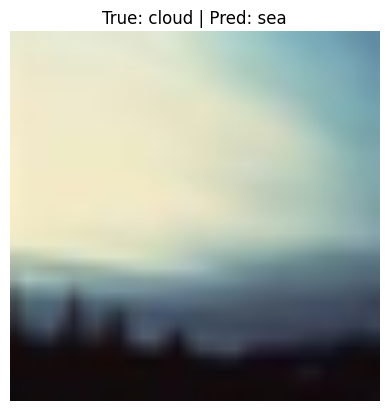

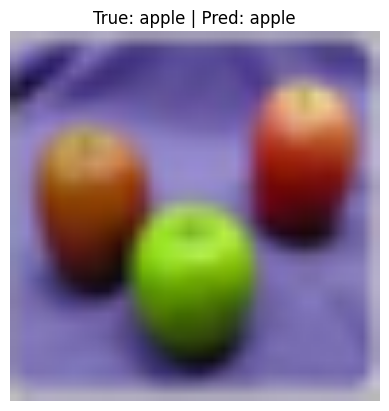

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

testset = torchvision.datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = testset.classes

# ---------------- LOAD MODEL ----------------
model = resnet18(weights=None)

model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(512, 100)
)

model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

print("Model Loaded")

# ---------------- PREDICTIONS ----------------
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---------------- METRICS ----------------
acc = accuracy_score(all_labels, all_preds)

print("\n✅ Accuracy:", acc)

print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ---------------- SHOW SAMPLE PREDICTIONS ----------------

def show_predictions(loader, model, classes, num_images=6):

    model.eval()

    images_shown = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):

                img = images[i].cpu().permute(1,2,0).numpy()

                true_label = classes[labels[i]]
                pred_label = classes[preds[i]]

                plt.imshow(img)
                plt.title(f"True: {true_label} | Pred: {pred_label}")
                plt.axis("off")
                plt.show()

                images_shown += 1

                if images_shown >= num_images:
                    return

show_predictions(testloader, model, classes, 10)

In [3]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=397e89446181bea1afa9260171f71d53c7ca4131e237faca08834af2528bb0bd
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Note: you may need to restart the kernel to use updated packages.


Model Loaded


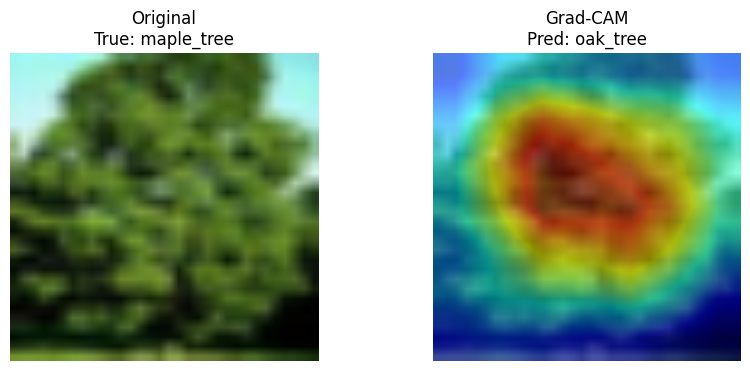

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset,batch_size=1,shuffle=True)

classes = dataset.classes

# ---------------- MODEL ----------------
model = resnet18(weights=None)

model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(512,100)
)

model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

print("Model Loaded")

# ---------------- TARGET LAYER ----------------
target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

# ---------------- GET ONE IMAGE ----------------
images,labels = next(iter(loader))

input_tensor = images.to(device)

# prediction
output = model(input_tensor)
pred_class = torch.argmax(output).item()

targets = [ClassifierOutputTarget(pred_class)]

# generate CAM
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

grayscale_cam = grayscale_cam[0]

# convert image for display
img = images[0].permute(1,2,0).numpy()

visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

# ---------------- DISPLAY ----------------

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Original\nTrue: {classes[labels.item()]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title(f"Grad-CAM\nPred: {classes[pred_class]}")
plt.axis("off")

plt.show()

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import random
import copy
import os
from torch.utils.data import random_split
# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)
# ---------------- DATA ----------------
# Enhanced train transform with ColorJitter and AutoAugment
transform_train = transforms.Compose([
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),  # CIFAR-specific policy
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor()
])
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])
trainset = torchvision.datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)
testset = torchvision.datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

# Validation split: 90% train, 10% val
train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size])
trainloader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)
valloader = torch.utils.data.DataLoader(
    val_subset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)
# ---------------- MODEL ----------------
model = resnet18(weights="IMAGENET1K_V1")
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(512, 100)
)
model = model.to(device)
# ---------------- FREEZE ALL ----------------
for p in model.parameters():
    p.requires_grad = False
# ---------------- ACCURACY FUNCTION ----------------
def accuracy_loader(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
    return correct / total
# ---------------- TRAINING SETUP ----------------
best_acc = accuracy_loader(model, testloader)
print("Initial test accuracy:", best_acc)
layers = {
    "layer1": model.layer1,
    "layer2": model.layer2,
    "layer3": model.layer3,
    "layer4": model.layer4
}
# Bias toward good layers (from previous run: layer2, layer3)
good_layers = ['layer2', 'layer3']
patience = 5
no_improve_count = 0
max_iterations = 40
# ---------------- RANDOMIZED TRAINING LOOP ----------------
for i in range(max_iterations):
    print("\n========== Iteration", i + 1, "==========")
    # Biased sampling: 70% chance to pick from good_layers
    if random.random() < 0.7:
        num_to_pick = random.choice([1, 2])
        if num_to_pick == 1:
            chosen_names = [random.choice(good_layers)]
        else:
            chosen_names = random.sample(good_layers, 2)
    else:
        chosen_names = random.sample(
            list(layers.keys()),
            random.choice([1, 2])
        )
    print("Unfreezing:", chosen_names)
    old_weights = copy.deepcopy(model.state_dict())
    # Unfreeze selected layers
    for name in chosen_names:
        for p in layers[name].parameters():
            p.requires_grad = True
    # Always train FC
    for p in model.fc.parameters():
        p.requires_grad = True
    # Updated optimizer: SGD with momentum, higher LR, adjusted WD
    optimizer = torch.optim.SGD(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
        momentum=0.9,
        nesterov=True,
        weight_decay=5e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=5  # Match increased epochs
    )
    loss_fn = torch.nn.CrossEntropyLoss()
    best_val_acc_iter = 0  # Track best val in this iteration
    # -------- TRAIN --------
    model.train()
    for epoch in range(5):  # Increased to 5 epochs
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()
        scheduler.step()
        # Val check every 2 epochs
        if epoch % 2 == 0:
            val_acc = accuracy_loader(model, valloader)
            print(f"  Epoch {epoch+1} Val Acc: {val_acc:.4f}")
            if val_acc > best_val_acc_iter:
                best_val_acc_iter = val_acc
    # -------- EVALUATE --------
    train_acc = accuracy_loader(model, trainloader)
    val_acc = accuracy_loader(model, valloader)  # Final val
    test_acc = accuracy_loader(model, testloader)
    print("Train Accuracy:", train_acc)
    print("Val Accuracy  :", val_acc)
    print("Test Accuracy :", test_acc)
    # -------- EARLY STOPPING (on test) --------
    if test_acc > best_acc:
        best_acc = test_acc
        no_improve_count = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Improved — Model Saved")
    else:
        model.load_state_dict(old_weights)
        no_improve_count += 1
        print("❌ Reverted | No Improve Count:", no_improve_count)
    # Freeze again
    for p in model.parameters():
        p.requires_grad = False
    # Stop if no improvement for patience rounds
    if no_improve_count >= patience:
        print("\n🛑 Early stopping triggered!")
        break
print("\nFinal Best Accuracy:", best_acc)
print("Best model saved as best_model.pth")

Using: cuda


100%|██████████| 169M/169M [00:02<00:00, 79.4MB/s] 


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s] 


Initial test accuracy: 0.0091

========== Iteration 1 ==========
Unfreezing: ['layer3', 'layer4']
  Epoch 1 Val Acc: 0.4266
  Epoch 3 Val Acc: 0.5596
  Epoch 5 Val Acc: 0.6118
Train Accuracy: 0.6428444444444444
Val Accuracy  : 0.6192
Test Accuracy : 0.7263
✅ Improved — Model Saved

========== Iteration 2 ==========
Unfreezing: ['layer3']
  Epoch 1 Val Acc: 0.6038
  Epoch 3 Val Acc: 0.6118
  Epoch 5 Val Acc: 0.6282
Train Accuracy: 0.6752888888888889
Val Accuracy  : 0.6356
Test Accuracy : 0.7418
✅ Improved — Model Saved

========== Iteration 3 ==========
Unfreezing: ['layer3']
  Epoch 1 Val Acc: 0.6298
  Epoch 3 Val Acc: 0.6262
  Epoch 5 Val Acc: 0.6562
Train Accuracy: 0.6946222222222223
Val Accuracy  : 0.6432
Test Accuracy : 0.7571
✅ Improved — Model Saved

========== Iteration 4 ==========
Unfreezing: ['layer2']
  Epoch 1 Val Acc: 0.6548
  Epoch 3 Val Acc: 0.6496
  Epoch 5 Val Acc: 0.6582
Train Accuracy: 0.7052888888888889
Val Accuracy  : 0.6632
Test Accuracy : 0.7629
✅ Improved — Mode